# Hipica-ML — Análisis Exploratorio de Datos (EDA)

Dataset: `data/processed/history.parquet` (long-form, una fila por carrera de cada caballo).

Construido a partir de 1 301 Tabuladas descargadas desde `hipica.maronas.com.uy`. El parquet contiene la **historia de carreras** de cada caballo que apareció en algún programa de Maroñas, incluyendo races corridas en otros tracks.

Objetivo de este notebook: documentar la forma del dataset, calidad, balance de clase y tendencias temporales, y guardar las figuras que se incluyen en el informe.

In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "history.parquet"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

df = pd.read_parquet(DATA_PATH)
print(f"Filas: {len(df):,}  ·  columnas: {df.shape[1]}")
df.head()

Filas: 98,398  ·  columnas: 17


,horse_name,race_date,racetrack_id,racetrack_abbr,finish_pos,in_trifecta,winner_name,kg,distance_m,total_time_s,dividend,jockey,body_weight_kg,source_file,sex_code,horse_age,post_position
0,A ALEJANDRA,2026-03-08,NaN,RCH,NaN,NaN,,NaN,NaN,NaN,54.0,-,NaN,Tabulada_RT1_20260419.xls,H,3,None
1,A BRILLAR,2025-03-29,13.0,L.PD,9.0,0.0,CRISTINA F,55.0,1100.0,70.87,50.3,Y. E. PEREIRA,55.0,Tabulada_RT1_20250413.xls,H,2,None
2,A BRILLAR,2025-03-29,13.0,L.PD,NaN,NaN,,NaN,NaN,NaN,55.0,24''16,NaN,Tabulada_RT1_20250831.xls,H,3,None
3,A BRILLAR,2025-04-13,1.0,MRÑ,8.0,0.0,TAP IT WIN,55.0,1100.0,68.43,52.5,Y. E. PEREIRA,55.0,Tabulada_RT1_20250504.xls,H,2,None
4,A BRILLAR,2025-04-13,1.0,MRÑ,NaN,NaN,,NaN,NaN,NaN,55.0,-,NaN,Tabulada_RT1_20250831.xls,H,3,None


## 1. Forma del dataset y rango temporal

In [3]:
n_rows, n_cols = df.shape
n_horses = df["horse_name"].nunique()
n_jockeys = df["jockey"].nunique()
n_tracks = df["racetrack_abbr"].nunique()
date_min, date_max = df["race_date"].min(), df["race_date"].max()

print(f"Filas:               {n_rows:,}")
print(f"Columnas:            {n_cols}")
print(f"Caballos únicos:     {n_horses:,}")
print(f"Jockeys únicos:      {n_jockeys:,}")
print(f"Tracks observados:   {n_tracks}")
print(f"Rango de fechas:     {date_min.date()}  →  {date_max.date()}")
print(f"Cobertura:           {(date_max - date_min).days / 365.25:.1f} años")

Filas:               98,398
Columnas:            17
Caballos únicos:     8,610
Jockeys únicos:      717
Tracks observados:   20
Rango de fechas:     2013-06-30  →  2026-05-31
Cobertura:           12.9 años


## 2. Calidad — missingness por columna

In [4]:
na_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
na_table = na_pct.to_frame("% NaN")
na_table["# NaN"] = df.isna().sum()
na_table["dtype"] = df.dtypes.astype(str)
na_table

,% NaN,# NaN,dtype
post_position,100.00,98398,object
total_time_s,38.30,37687,float64
dividend,22.10,21746,float64
distance_m,16.09,15828,float64
in_trifecta,16.06,15803,float64
finish_pos,16.06,15803,float64
kg,15.89,15640,float64
body_weight_kg,11.36,11174,float64
racetrack_id,1.14,1121,float64
horse_name,0.00,0,object


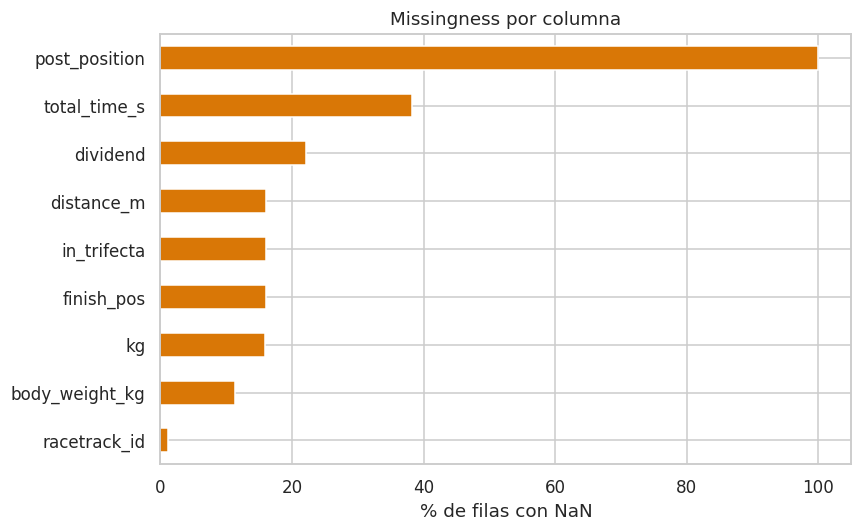

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
na_pct[na_pct > 0].plot(kind="barh", ax=ax, color="#d97706")
ax.set_xlabel("% de filas con NaN")
ax.set_title("Missingness por columna")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIG_DIR / "01_missingness.png")
plt.show()

**Interpretación.** `post_position` es 100 % NaN porque la Tabulada no expone la posición de partida histórica del caballo (ver §8.6 de `CLAUDE.md`); a tiempo de servir se completa con el dato de la carrera del día. `finish_pos` y `in_trifecta` están NaN en el mismo 16 % de filas: corresponden a corridas con resultados especiales (`DSC`, `RTD`) que el loader deja como NaN. En el entrenamiento estas filas se descartan.

## 3. Balance de clase (`in_trifecta`)

Filas etiquetadas:   82,595  (83.9% del total)
in_trifecta = 1:     29,533  (35.76%)
in_trifecta = 0:     53,062  (64.24%)


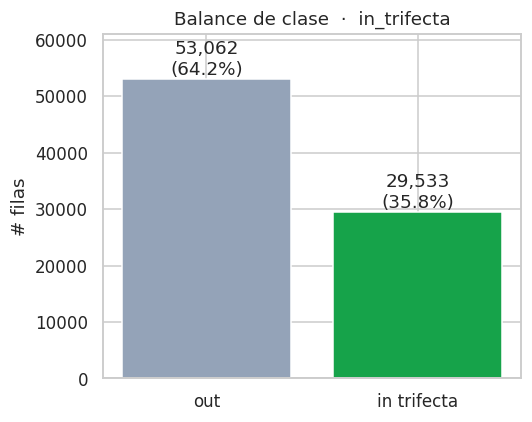

In [6]:
labelled = df.dropna(subset=["in_trifecta"]).copy()
labelled["in_trifecta"] = labelled["in_trifecta"].astype(int)
rate = labelled["in_trifecta"].mean()
counts = labelled["in_trifecta"].value_counts().sort_index()

print(f"Filas etiquetadas:   {len(labelled):,}  ({len(labelled)/len(df):.1%} del total)")
print(f"in_trifecta = 1:     {counts.get(1, 0):,}  ({rate:.2%})")
print(f"in_trifecta = 0:     {counts.get(0, 0):,}  ({1-rate:.2%})")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["out", "in trifecta"], counts.values, color=["#94a3b8", "#16a34a"])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({v/counts.sum():.1%})", ha="center", va="bottom")
ax.set_ylabel("# filas")
ax.set_title("Balance de clase  ·  in_trifecta")
ax.set_ylim(0, counts.max() * 1.15)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_label_balance.png")
plt.show()

## 4. Distribuciones de variables numéricas

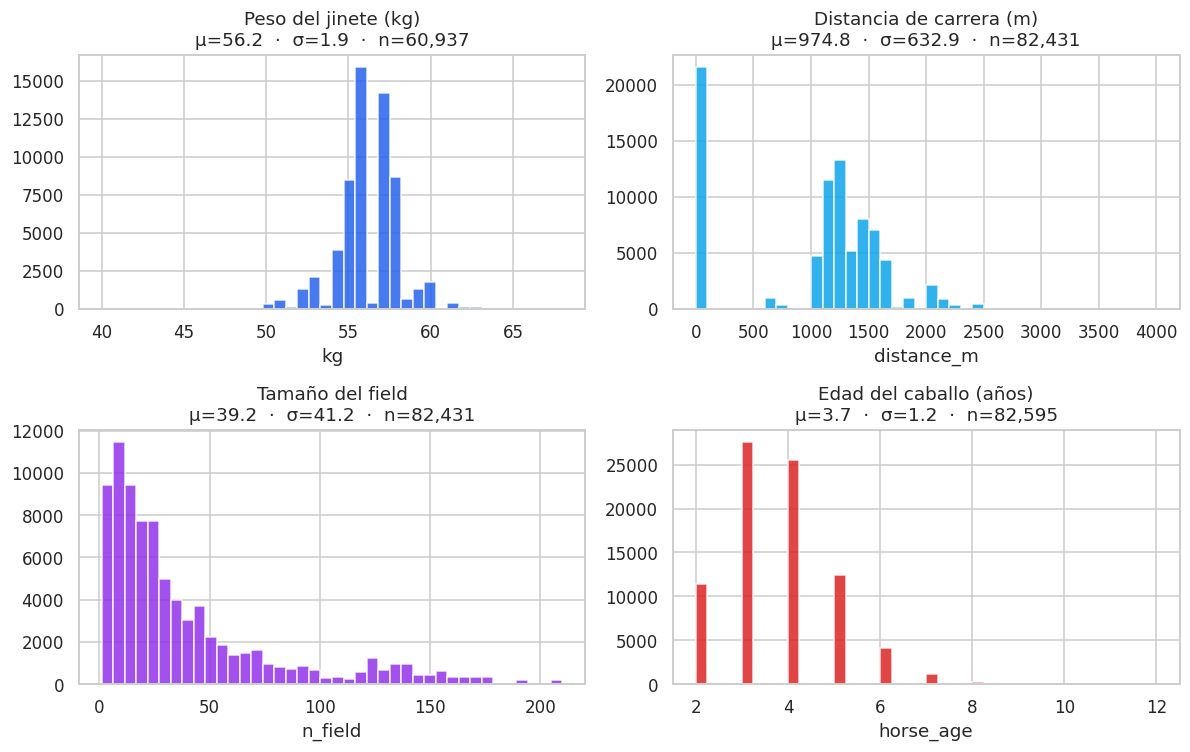

In [7]:
labelled["n_field"] = labelled.groupby(["race_date", "racetrack_abbr", "distance_m"])["horse_name"].transform("size")

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
specs = [
    ("kg",         "Peso del jinete (kg)",       (40, 70),  "#2563eb"),
    ("distance_m", "Distancia de carrera (m)",   (None, None), "#0ea5e9"),
    ("n_field",    "Tamaño del field",           (None, None), "#9333ea"),
    ("horse_age",  "Edad del caballo (años)",   (None, None), "#dc2626"),
]
for ax, (col, title, clip, color) in zip(axes.flat, specs):
    s = labelled[col].dropna()
    if clip[0] is not None:
        s = s[(s >= clip[0]) & (s <= clip[1])]
    ax.hist(s, bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"{title}\nμ={s.mean():.1f}  ·  σ={s.std():.1f}  ·  n={len(s):,}")
    ax.set_xlabel(col)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_numeric_distributions.png")
plt.show()

## 5. Tracks y jockeys más frecuentes

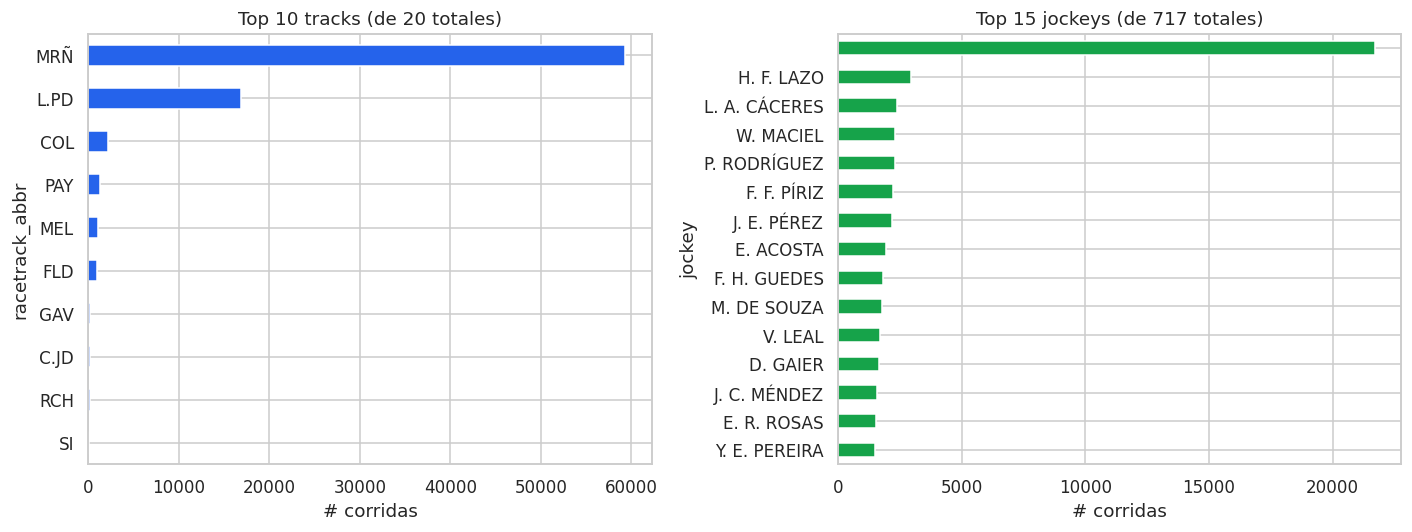

In [8]:
top_tracks = labelled["racetrack_abbr"].value_counts().head(10)
top_jockeys = labelled["jockey"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top_tracks.plot(kind="barh", ax=axes[0], color="#2563eb")
axes[0].set_title(f"Top 10 tracks (de {df['racetrack_abbr'].nunique()} totales)")
axes[0].set_xlabel("# corridas")
axes[0].invert_yaxis()

top_jockeys.plot(kind="barh", ax=axes[1], color="#16a34a")
axes[1].set_title(f"Top 15 jockeys (de {df['jockey'].nunique():,} totales)")
axes[1].set_xlabel("# corridas")
axes[1].invert_yaxis()
fig.tight_layout()
fig.savefig(FIG_DIR / "04_top_tracks_jockeys.png")
plt.show()

## 6. Cuántas carreras tiene cada caballo (distribución de cola larga)

count    8610.00
mean       11.43
std         9.27
min         1.00
25%         5.00
50%         9.00
75%        16.00
max        74.00


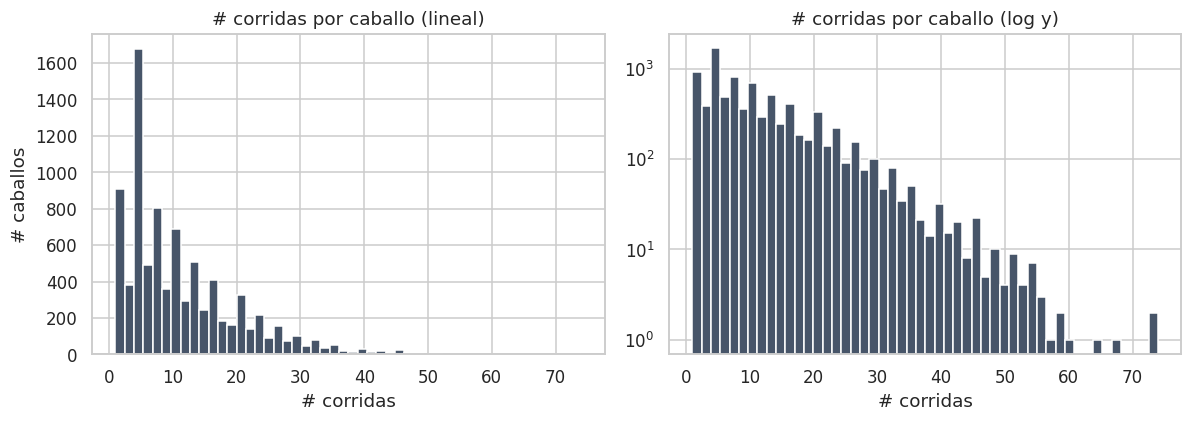

In [9]:
runs_per_horse = df.groupby("horse_name").size()
print(runs_per_horse.describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(runs_per_horse, bins=50, color="#475569", edgecolor="white")
axes[0].set_title("# corridas por caballo (lineal)")
axes[0].set_xlabel("# corridas")
axes[0].set_ylabel("# caballos")

axes[1].hist(runs_per_horse, bins=50, color="#475569", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("# corridas por caballo (log y)")
axes[1].set_xlabel("# corridas")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_runs_per_horse.png")
plt.show()

## 7. Tendencias temporales — carreras y tasa de label por año

In [10]:
by_year = (
    labelled.assign(year=labelled["race_date"].dt.year)
    .groupby("year")
    .agg(n_rows=("in_trifecta", "size"), label_rate=("in_trifecta", "mean"))
)
by_year

,n_rows,label_rate
year,,
2013,1,0.000000
2014,12,0.416667
2015,144,0.305556
2016,2080,0.359615
2017,14820,0.353711
2018,7267,0.340030
2019,15506,0.338966
2020,3127,0.322993
2021,178,0.314607


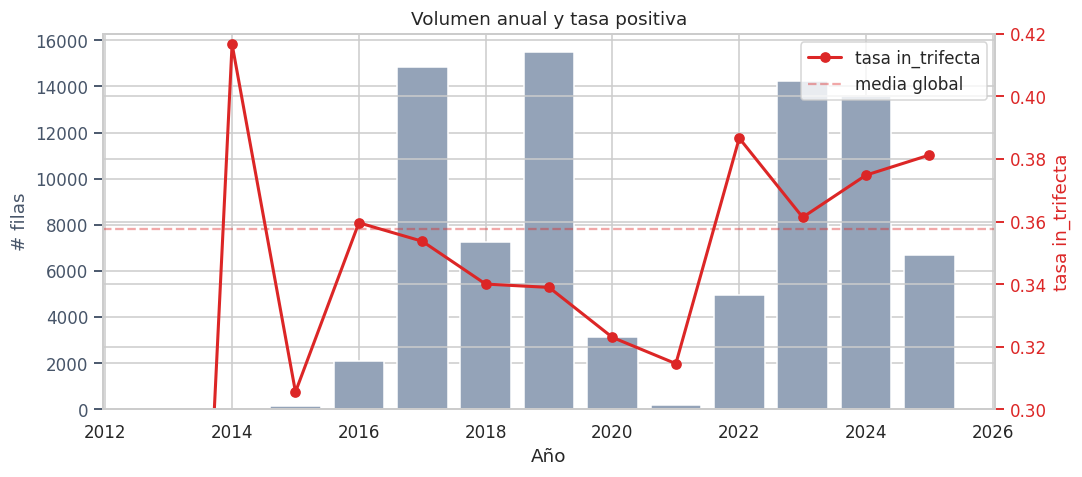

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(by_year.index, by_year["n_rows"], color="#94a3b8", label="# filas")
ax1.set_xlabel("Año")
ax1.set_ylabel("# filas", color="#475569")
ax1.tick_params(axis="y", colors="#475569")

ax2 = ax1.twinx()
ax2.plot(by_year.index, by_year["label_rate"], color="#dc2626", marker="o", lw=2, label="tasa in_trifecta")
ax2.axhline(labelled["in_trifecta"].mean(), color="#dc2626", ls="--", alpha=0.4, label="media global")
ax2.set_ylabel("tasa in_trifecta", color="#dc2626")
ax2.tick_params(axis="y", colors="#dc2626")
ax2.set_ylim(0.30, 0.42)

ax1.set_title("Volumen anual y tasa positiva")
ax2.legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_temporal_trends.png")
plt.show()

## 8. Correlación de variables numéricas

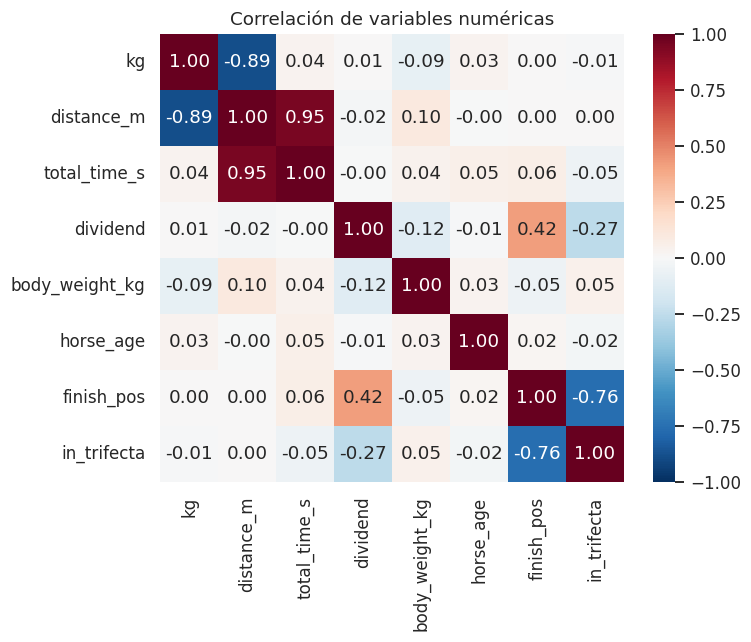

In [12]:
num_cols = ["kg", "distance_m", "total_time_s", "dividend", "body_weight_kg", "horse_age", "finish_pos", "in_trifecta"]
corr = labelled[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación de variables numéricas")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_correlation.png")
plt.show()

**Interpretación.** `dividend` correlaciona negativamente con `in_trifecta` (≈ −0.20): los caballos con dividendos bajos (favoritos) entran más a la trifecta. `total_time_s` y `distance_m` son colineales (más metros, más tiempo) — esperado. `kg` (peso del jinete) tiene correlación débil con el target.

## 9. Tasa de label por track y por bucket de distancia

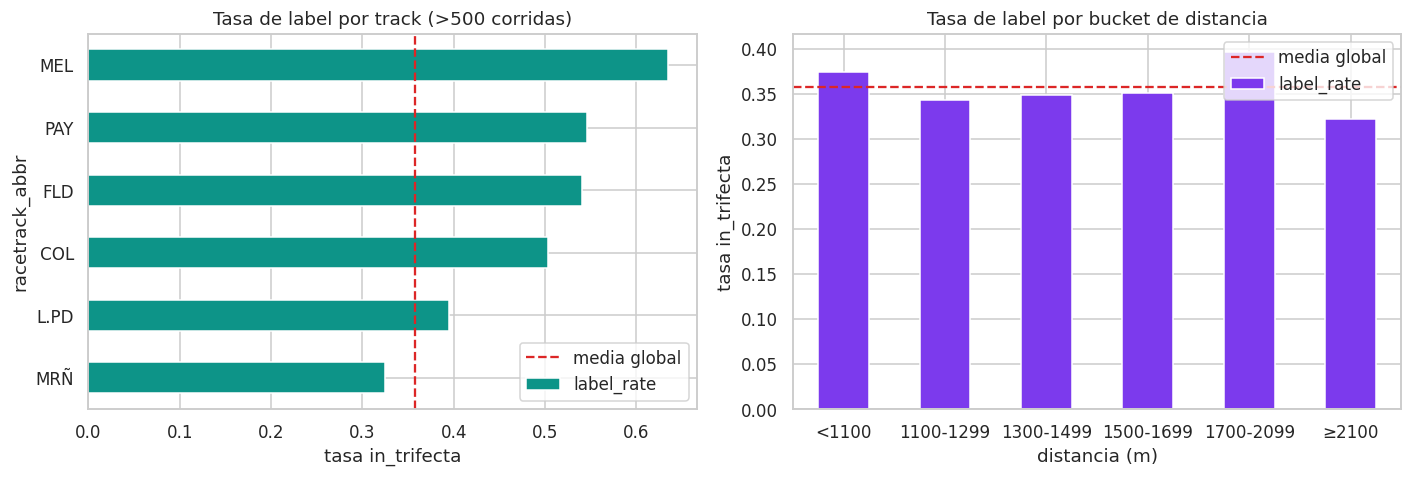


Por track:
                label_rate  n_rows
racetrack_abbr                    
MEL                  0.635    1037
PAY                  0.546    1307
FLD                  0.540     990
COL                  0.503    2128
L.PD                 0.395   16910
MRÑ                  0.325   59256

Por bucket de distancia:
             label_rate  n_rows
dist_bucket                    
<1100             0.374   27824
1100-1299         0.343   24878
1300-1499         0.348   13156
1500-1699         0.351   11409
1700-2099         0.397    3363
≥2100             0.322    1800


In [13]:
by_track = (
    labelled.groupby("racetrack_abbr")["in_trifecta"]
    .agg(["mean", "size"])
    .query("size >= 500")
    .sort_values("mean", ascending=False)
)
by_track.columns = ["label_rate", "n_rows"]

bins = [0, 1100, 1300, 1500, 1700, 2100, 4000]
labels = ["<1100", "1100-1299", "1300-1499", "1500-1699", "1700-2099", "≥2100"]
labelled["dist_bucket"] = pd.cut(labelled["distance_m"], bins=bins, labels=labels, right=False)
by_dist = (
    labelled.groupby("dist_bucket", observed=True)["in_trifecta"]
    .agg(["mean", "size"])
)
by_dist.columns = ["label_rate", "n_rows"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
by_track["label_rate"].plot(kind="barh", ax=axes[0], color="#0d9488")
axes[0].axvline(labelled["in_trifecta"].mean(), color="#dc2626", ls="--", label="media global")
axes[0].set_title("Tasa de label por track (>500 corridas)")
axes[0].set_xlabel("tasa in_trifecta")
axes[0].invert_yaxis()
axes[0].legend()

by_dist["label_rate"].plot(kind="bar", ax=axes[1], color="#7c3aed")
axes[1].axhline(labelled["in_trifecta"].mean(), color="#dc2626", ls="--", label="media global")
axes[1].set_title("Tasa de label por bucket de distancia")
axes[1].set_ylabel("tasa in_trifecta")
axes[1].set_xlabel("distancia (m)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "08_balance_by_segment.png")
plt.show()

print("\nPor track:")
print(by_track.round(3).to_string())
print("\nPor bucket de distancia:")
print(by_dist.round(3).to_string())

## 10. Resumen

### Hallazgos principales

- **Volumen.** 98 398 filas, 8 610 caballos únicos, 13 años de cobertura (2013-06-30 → 2026-05-31).
- **Tracks.** Aunque el scraper sólo pide Tabuladas de Maroñas (`racetrack_id=1`), las historias incluyen ~20 tracks porque cada caballo lista todas sus corridas previas en cualquier hipódromo.
- **Calidad.** `post_position` es 100 % NaN por diseño (no aparece en la Tabulada); `finish_pos` y `in_trifecta` están NaN en ~16 % por descalificaciones (`DSC`, `RTD`). Esas filas se descartan al entrenar.
- **Balance.** El target tiene 35.76 % positivos — **no requiere class weighting agresivo**, pero conviene reportar PR-AUC además de ROC-AUC.
- **Cola larga de caballos.** La mediana de corridas por caballo es baja, con una cola larga de caballos veteranos. Los rookies dominan en número.
- **Drift temporal.** La tasa de label por año oscila entre ~33 % y ~38 %: estable. No hay ruptura estructural que justifique reentrenar por época.
- **Señal de mercado.** `dividend` correlaciona negativamente con `in_trifecta` (≈ −0.20). Esa señal, agregada como feature de carrera (`dividend_career_mean`, `dividend_last3_mean`, `dividend_career_min`), fue la que más movió la métrica entre v3 y v4.

### Próximos pasos

- Ver `notebooks/02_explainability.ipynb` para SHAP sobre el modelo entrenado.
- Ver `notebooks/03_feature_selection.ipynb` para reducción de las 35 features.